# Assignment 1

In [1]:
!pip install -q ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 16.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk, molecule, make_supercell
from ase.visualize.plot import plot_atoms

plt.rcParams['figure.dpi'] = 110

Build and visualize the following structures. For each, report the number of atoms in the primitive cell. Also, answer the associated questions.

 NaCl (rock salt) — a binary ionic crystal with a 2-atom basis with a=5.64 A. How does its structure relate to the FCC lattice you already built for Al?

In [7]:
NaCl = bulk('NaCl',"rocksalt",a=5.64)
n = len(NaCl)
print("no of atoms in primitive cell:",n)

no of atoms in primitive cell: 2


In [8]:
from ase.visualize import view

view(NaCl, viewer='x3d')

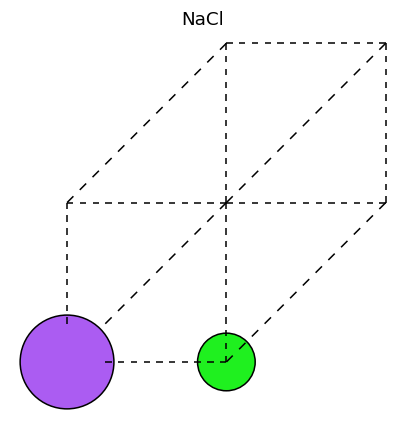

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
plot_atoms(NaCl, ax, radii=0.5, show_unit_cell=2)
ax.set_title("NaCl")
ax.set_axis_off()
plt.tight_layout()
plt.show()

We can observe that the primitive cell is the same as aluminium as they are both fcc, however in Nacl we have two atoms per lattice point in the cell

BaTiO₃ (perovskite)

In [14]:
lp = 4.036 #Lattice Parameter
sym = ['Ba','Ti','O','O','O']
pos = [(0,0,0),(0.5,0.5,0.5),(0,0.5,0.5),(0.5,0,0.5),(0.5,0.5,0)]

BaTiO3 = Atoms(
    symbols= sym,
    scaled_positions=pos,   # fractional (crystal) coordinates
    cell=[[lp, 0, 0], [0, lp, 0], [0, 0, lp]],   # cubic cell
    pbc=True,
)
print('No of atoms:',len(BaTiO3))
from ase.visualize import view

view(BaTiO3, viewer='x3d')


No of atoms: 5


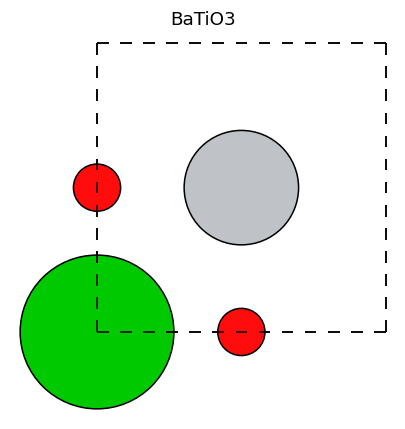

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
plot_atoms(BaTiO3, ax, radii=0.5, show_unit_cell=2)
ax.set_title("BaTiO3")
ax.set_axis_off()
plt.tight_layout()
plt.show()

start from a Cu FCC supercell and randomly replace ~20% of the Cu atoms with Ni. Visualize it. Does it still look like a 'crystal' to you?

In [16]:
#let us create a 3x3x3 super cell of Cu FCC , lattice param is approx 3.6
Cu = bulk('Cu', 'fcc', a=3.6)
Cu_ss = Cu.repeat((3, 3, 3)) #super cell
print(len(Cu_ss))

27


In [23]:
#20 percent of 27 atoms is 5.4, so i will replace 5 random Cu with Ni
#first of all I will choose 5 random numbers
import random
random.seed(10)   #to ensure reproducability

r = []
while len(r) !=5:
  i = random.randint(0, 26)
  if i not in r:
    r.append(i)
print(r)


[18, 1, 13, 15, 0]


In [26]:
for ttk in r:
  Cu_ss[ttk].symbol = 'Ni'
print(Cu_ss.get_chemical_formula())

Cu22Ni5


In [27]:
from ase.visualize import view
view(Cu_ss, viewer='x3d')

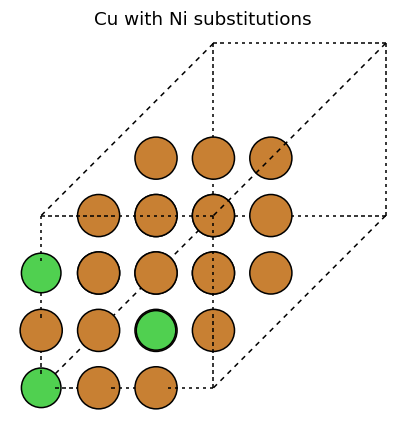

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
plot_atoms(Cu_ss, ax, radii=0.5, show_unit_cell=2)
ax.set_title("Cu with Ni substitutions")
ax.set_axis_off()
plt.tight_layout()
plt.show()

While it doesn't "look like a crystal", since we will be putting periodic boundary conditions, it is a crystal. However, if he had sunstituted 20% randomly from all the crystal instead of from the unit cell, it wont be a crystal anymore as it loses its translational symmetry

# Discuss / Explain

**Why is the shape of the H2O and the CO2 molecules different even though they both are symmetric about the central atom?**

H2O and CO2 have different Hybridisation. H2O,being Sp3 with a lone pair , exhibits bent shape, while CO2,being Sp2 with no lone pair, is linear

**Why is the diamond-cubic structure so much less densely packed than FCC or BCC, even though every atom is still bonded to its nearest neighbors?**

Diamond cubic structure is covalently bonded and is sp3 hybriised, this constraints the system to be of tetrahedral geometry with coordination number of 4, on the other hand, in bcc and fcc, we observe metallic bonding that doesn not impose any constraint on the coordination number or the geometry and hence could be more tightly packed

**You built both a primitive cell and a conventional cell for the same physical crystal. In what sense are they 'the same crystal' despite having different numbers of atoms in the box ASE reports?**

Both primitve and conventional cells are two different reprsentations of the same crystal. What this means is that we will get the exact same crystal structure by translating both the cell throughout space

**When you built the silicon vacancy, only the neighbors immediately around the missing atom moved (conceptually — we didn't relax positions here, but imagine we had). Why would a larger supercell be necessary if you wanted the vacancy's effect to be 'diluted' rather than interacting with its own periodic images?**

Say we use a 3x3x3 super cell and add one vacancy to it, due to periodic boundary conditions, that means we hav one vacancy on every side per 3 atom. We can dilute the same by adding one vacancy in 6x6x6 unit cell, with the increase in super cell dimension by 2, the concentraion of vacancies go down by 8 times (2^3). This prevents the vaacancies from interacting with its own periodic images and thus would give us a more accurate answer when it comes to energy calculations like formation energy for the vacancies.